## Playing around with attendance data

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

cities = pd.read_csv("../data/cities.csv")

# I'm going to assume "trip" == "event"
events = pd.read_excel("../data/MHC Trip Summary.xlsx")
# Remove nans for city and site type 
events = events.dropna(subset=["City", "Site Types"])

# Remove rows that have only nan
nan2zero_cols = "All Women (not pregnant 18+)", "Pregnant Patients (all ages)", "Children 1-18 years", "All infants <1 year"
non_all_nan_rows = ~np.all(np.isnan(events.loc[:, nan2zero_cols].values), axis=1)
events = events.loc[non_all_nan_rows,:]

# Fill the remaining gaps with zeros
events.loc[:,nan2zero_cols] = events.loc[:,nan2zero_cols].fillna(0)


events = pd.merge(events, cities.loc[:,["city","pop"]], left_on="City", right_on="city")

# Split multi-valued items
events["Site Types"] = events["Site Types"].apply(lambda st : np.array(st.split(";")) )

# Total foot traffic calculation
events["Foot traffic"] = events["All Men"] + events["All Women (not pregnant 18+)"] + events["Pregnant Patients (all ages)"] + events["Children 1-18 years"] + events["All infants <1 year"]


display(events)



,Date,City,Physical location,Site Types,Latitude,Longitude,Organizer,Services offered,Total Pharmacists,Total APPE Students,...,Patients referred to Healthwise MC.1,Patients referred to other sites.1,Patients needing f/u.1,Patients who were seen at f/u.1,Patients not seen at f/u.1,New diagnosis noted at f/u.1,Interventions made at appointment.1,city,pop,Foot traffic
0,2024-08-02 00:00:00,Ottawa,Ottawa Schools,[Special Event],41.028836,-84.046572,HealthWise,BP + BG,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ottawa,4456,28.0
1,9/10/2024-9/13/2024,Kenton,Hardin County Fairgrounds,[Special Event],40.631205,-83.610080,NaN,"BP, BG, lipids",4,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kenton,7947,60.0
2,2024-09-21 00:00:00,Ada,Downtown Ada,[Special Event],40.769433,-83.823181,Harvest and Herb,BP + BG + lipids,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ada,5334,16.0
3,2024-09-21 00:00:00,Lima,Reading Park,[Special Event],40.742964,-84.120592,Mercy Block Party,BP,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,30.0
4,2024-09-24 00:00:00,Lima,AAA Lima,[Special Event],40.748349,-84.148803,AAA Falls Day,BP + BMD,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,2025-05-02 00:00:00,Ada,ONU Day of Giving,[Special Event],40.769433,-83.823181,HW,BP,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ada,5334,18.0
74,2025-05-06 00:00:00,Lima,Mercy Thrift Store,[Thrift store],40.743039,-84.111477,HealthWise,MHC,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,4.0
75,2025-05-07 00:00:00,Lima,Christian Corner,[Food Bank],40.712793,-84.107995,HealthWise,MHC,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lima,35579,7.0
76,2025-05-08 00:00:00,Bluffton,Bluffton Library,[Library],40.892385,-83.892901,HealthWise,NaN,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bluffton,3967,3.0


## Helper functions

In [187]:
def plot_site_type(events, site_type=None, legend=True):

    site_type_mask = np.logical_not(events["Site Types"].apply(lambda t : (t == "Special Event").all()))


    if site_type != None: 
        site_type_mask = np.logical_and(site_type_mask, events["Site Types"].apply(lambda t : (t == site_type).any()))

    events = events.loc[site_type_mask,:]

    site_set = set(events["Physical location"])

    fig, ax = plt.subplots()

    for site in site_set:
        pops         = events.loc[events["Physical location"] == site,"pop"]
        foot_traffic = events.loc[events["Physical location"] == site,"Foot traffic"]

        current_city = events.loc[events["Physical location"] == site,"city"].values[0]

        label = f"{current_city}: {site}"
        ax.scatter(pops, foot_traffic, label=label)

    if legend:
        plt.legend()

    if site_type is not None:
        plt.title(f"Expected attendance at {site_type} sites")
    else:
        plt.title(f"Expected attendance across all sites")

    fig.set_size_inches(8, 5)

    plt.show()

## Examining attenance as a function of population and site type
_Reflections_: It doesn't seem that population is a big determinant of expected attendance 

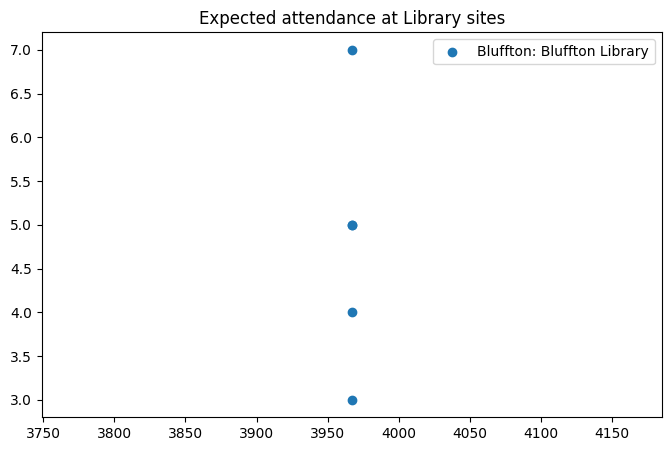

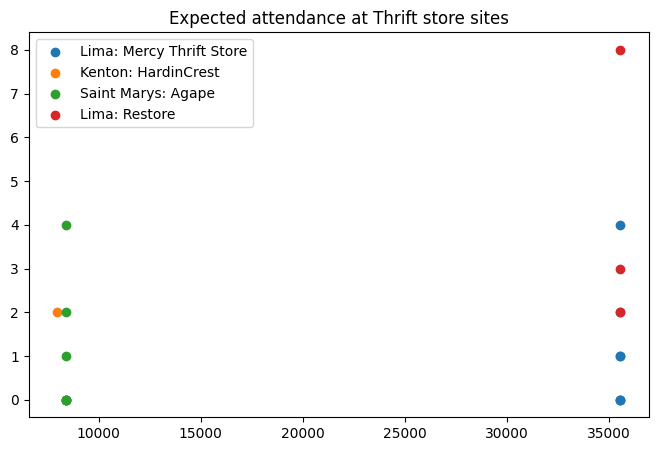

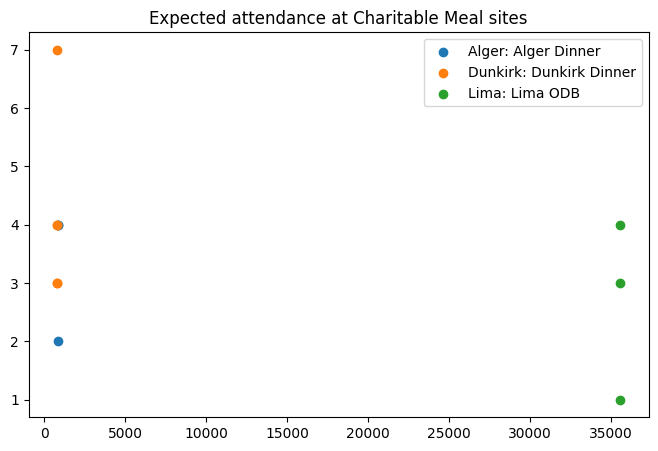

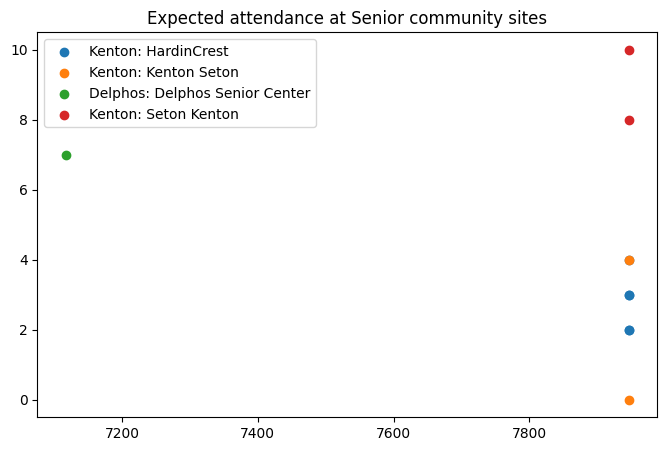

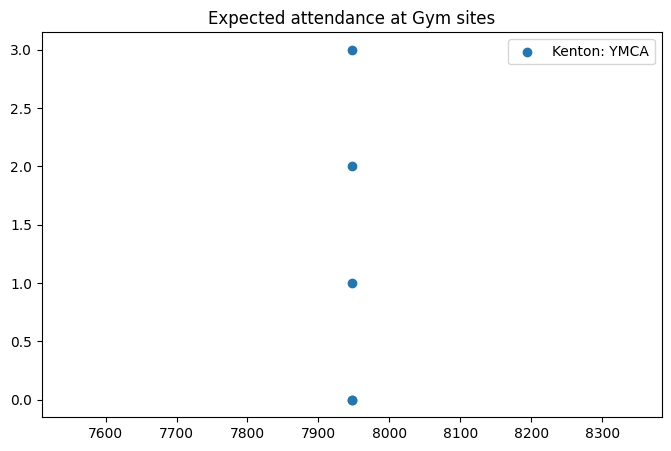

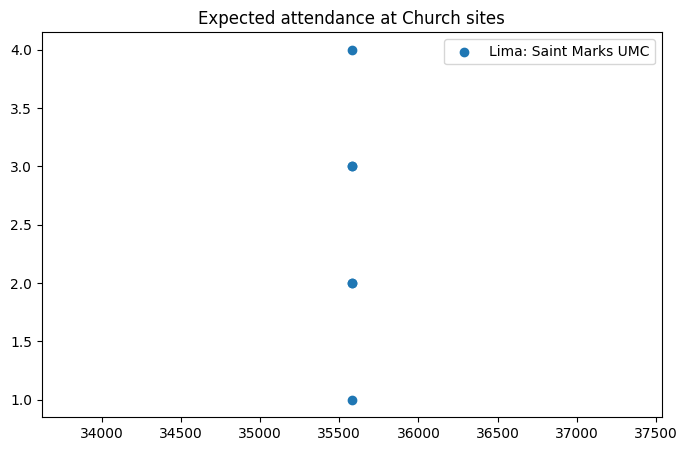

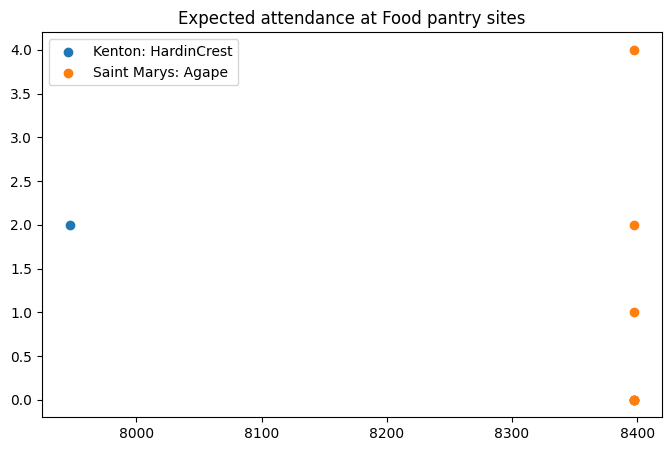

In [189]:
plot_site_type(events, site_type="Library")
plot_site_type(events, site_type="Thrift store")
plot_site_type(events, site_type='Charitable Meal')
plot_site_type(events, site_type="Senior community")
plot_site_type(events, site_type="Gym")
plot_site_type(events, site_type="Church")
plot_site_type(events, "Food pantry")

## Examining attendance as a function of population
_Reflections:_ It looks like population really isn't a big determinant of expected attendance 

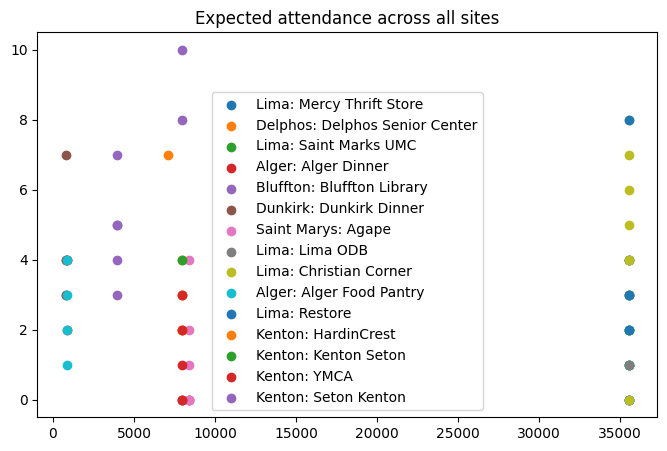

In [188]:
plot_site_type(events, legend=True)